In [44]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import datetime, timedelta
import matplotlib.dates as mdates
from scipy import stats
from prophet import Prophet
import ipynb.fs.full.eda as eda # type: ignore
from statsmodels.tsa.seasonal import seasonal_decompose, STL
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from statsmodels.tsa.stattools import adfuller

In [45]:
df = eda.load_and_prepare_data('taxi-dataset.parquet')

Loading data...

Dataset Shape: (3152677, 19)

Columns with missing values:
VendorID                     0
tpep_pickup_datetime         0
tpep_dropoff_datetime        0
passenger_count          93174
trip_distance                0
RatecodeID               93174
store_and_fwd_flag       93174
PULocationID                 0
DOLocationID                 0
payment_type                 0
fare_amount                  0
extra                        0
mta_tax                      0
tip_amount                   0
tolls_amount                 0
improvement_surcharge        0
total_amount                 0
congestion_surcharge     93174
airport_fee              93174
dtype: int64


In [46]:
print(df.columns)
print(df.head())

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee', 'trip_duration',
       'pickup_hour', 'pickup_day', 'pickup_date', 'pickup_month',
       'pickup_year', 'pickup_dayofweek', 'tip_percentage',
       'payment_type_desc', 'trip_distance_filtered', 'fare_amount_filtered',
       'trip_duration_filtered'],
      dtype='object')
   VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0         1  2022-08-01 00:17:39   2022-08-01 00:19:58              1.0   
1         1  2022-08-01 00:26:06   2022-08-01 00:31:55              1.0   
2         1  2022-08-01 00:45:49   2022-08-01 00:59:29              1.0   
3         1  2022-08-01 00:05:49   2022-08-01 00:25:42       

In [47]:
# get 2022 data
df_2022 = df[df['tpep_pickup_datetime'].dt.year == 2022]
print(df_2022.head())
eda.time_series_decomposition(df_2022)

   VendorID tpep_pickup_datetime tpep_dropoff_datetime  passenger_count  \
0         1  2022-08-01 00:17:39   2022-08-01 00:19:58              1.0   
1         1  2022-08-01 00:26:06   2022-08-01 00:31:55              1.0   
2         1  2022-08-01 00:45:49   2022-08-01 00:59:29              1.0   
3         1  2022-08-01 00:05:49   2022-08-01 00:25:42              1.0   
4         1  2022-08-01 00:36:29   2022-08-01 00:51:29              1.0   

   trip_distance  RatecodeID store_and_fwd_flag  PULocationID  DOLocationID  \
0            0.4         1.0                  N           114           148   
1            1.4         1.0                  N            79           137   
2            5.2         1.0                  N            79            74   
3            9.4         1.0                  N           138           113   
4            1.7         1.0                  N           137            68   

   payment_type  ...  pickup_day  pickup_date  pickup_month  pickup_year  

In [48]:
eda.time_series_decomposition(df)


--- Time Series Decomposition ---
Unable to perform time series decomposition: Unable to determine period from endog
Make sure statsmodels is installed: pip install statsmodels


In [49]:
def stationarity_test(df):
    from statsmodels.tsa.stattools import adfuller
    result = adfuller(df.groupby('pickup_date').size())
    print('ADF Statistic: %f' % result[0])
    print('p-value: %f' % result[1])
    print('Critical Values:')
    for key, value in result[4].items():
        print('\t%s: %.3f' % (key, value))

stationarity_test(df)

ADF Statistic: -2.766093
p-value: 0.063283
Critical Values:
	1%: -3.639
	5%: -2.951
	10%: -2.614


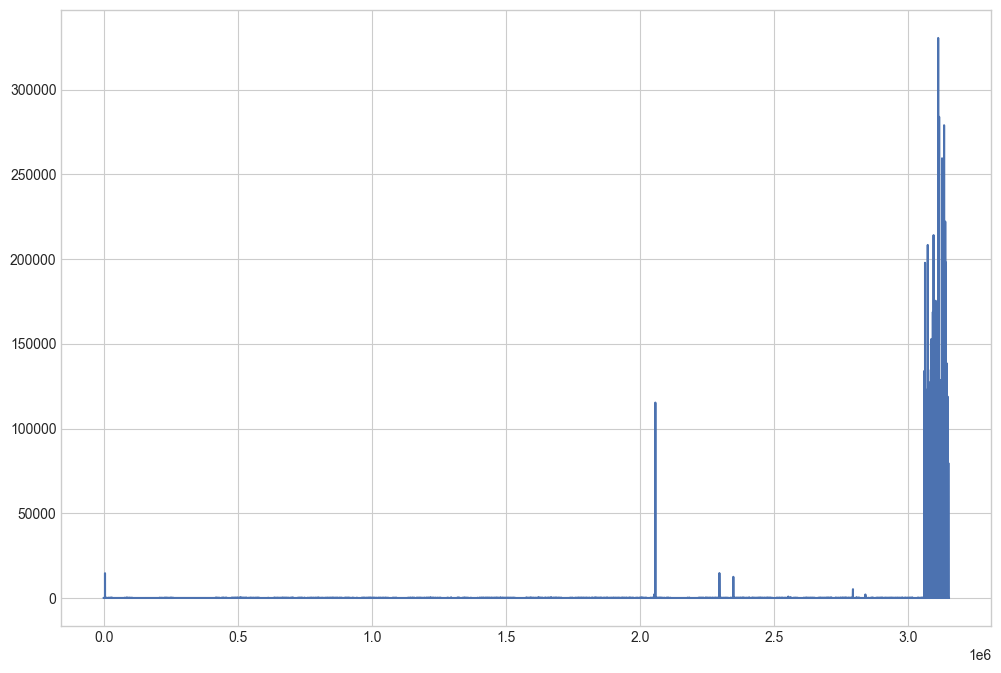

In [50]:
plt.plot(df['trip_distance'])
plt.show()

Index(['VendorID', 'tpep_pickup_datetime', 'tpep_dropoff_datetime',
       'passenger_count', 'trip_distance', 'RatecodeID', 'store_and_fwd_flag',
       'PULocationID', 'DOLocationID', 'payment_type', 'fare_amount', 'extra',
       'mta_tax', 'tip_amount', 'tolls_amount', 'improvement_surcharge',
       'total_amount', 'congestion_surcharge', 'airport_fee', 'trip_duration',
       'pickup_hour', 'pickup_day', 'pickup_date', 'pickup_month',
       'pickup_year', 'pickup_dayofweek', 'tip_percentage',
       'payment_type_desc', 'trip_distance_filtered', 'fare_amount_filtered',
       'trip_duration_filtered', 'fare_rate'],
      dtype='object')


/var/folders/04/5q_s1_k517b51_bnqnv3h4k40000gn/T/ipykernel_82736/1603796042.py:17: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_fare_rate = df.resample('H')['fare_rate'].mean()
/var/folders/04/5q_s1_k517b51_bnqnv3h4k40000gn/T/ipykernel_82736/1603796042.py:23: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_fare_rate = df.resample('M')['fare_rate'].mean()


Decomposing fare rate time series at different time scales...



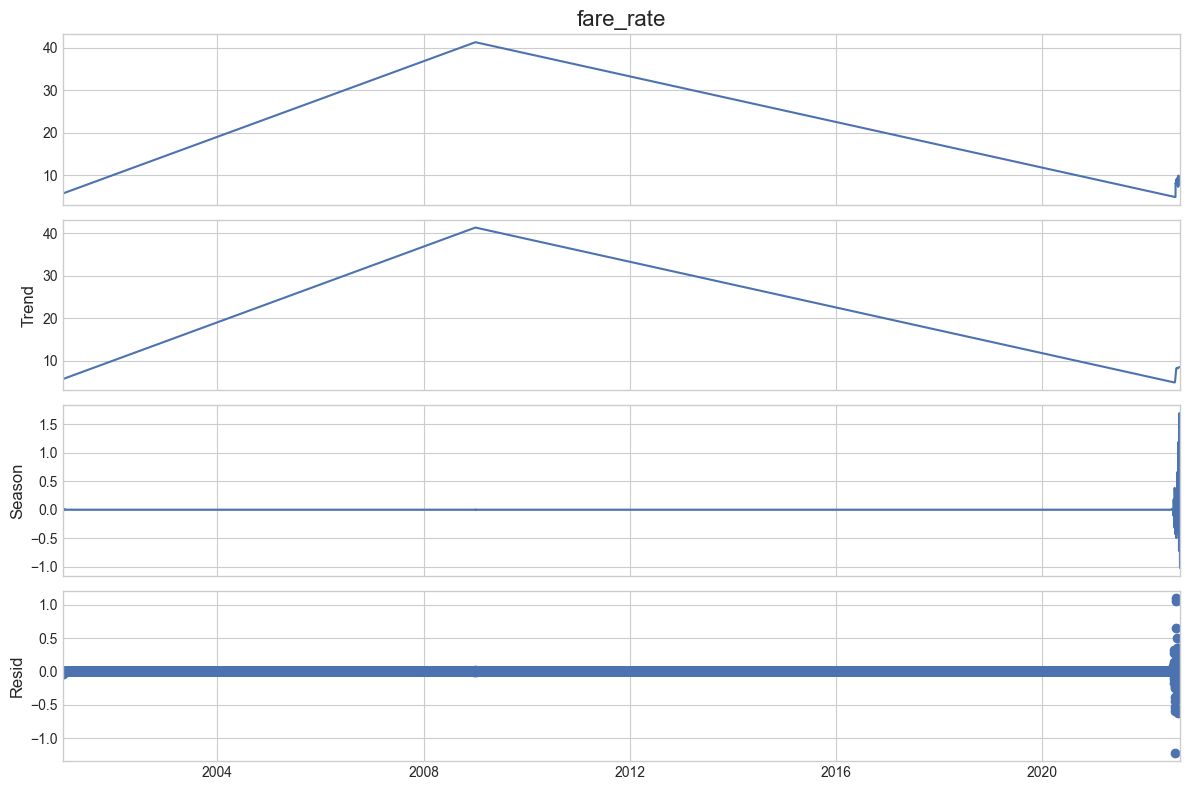

Stationarity Test for Residuals in Daily Average Fare Rate
ADF Statistic: -32.6965
p-value: 0.0000
Critical Values:
	1%: -3.4312
	5%: -2.8619
	10%: -2.5670
Residuals are stationary (p-value < 0.05)




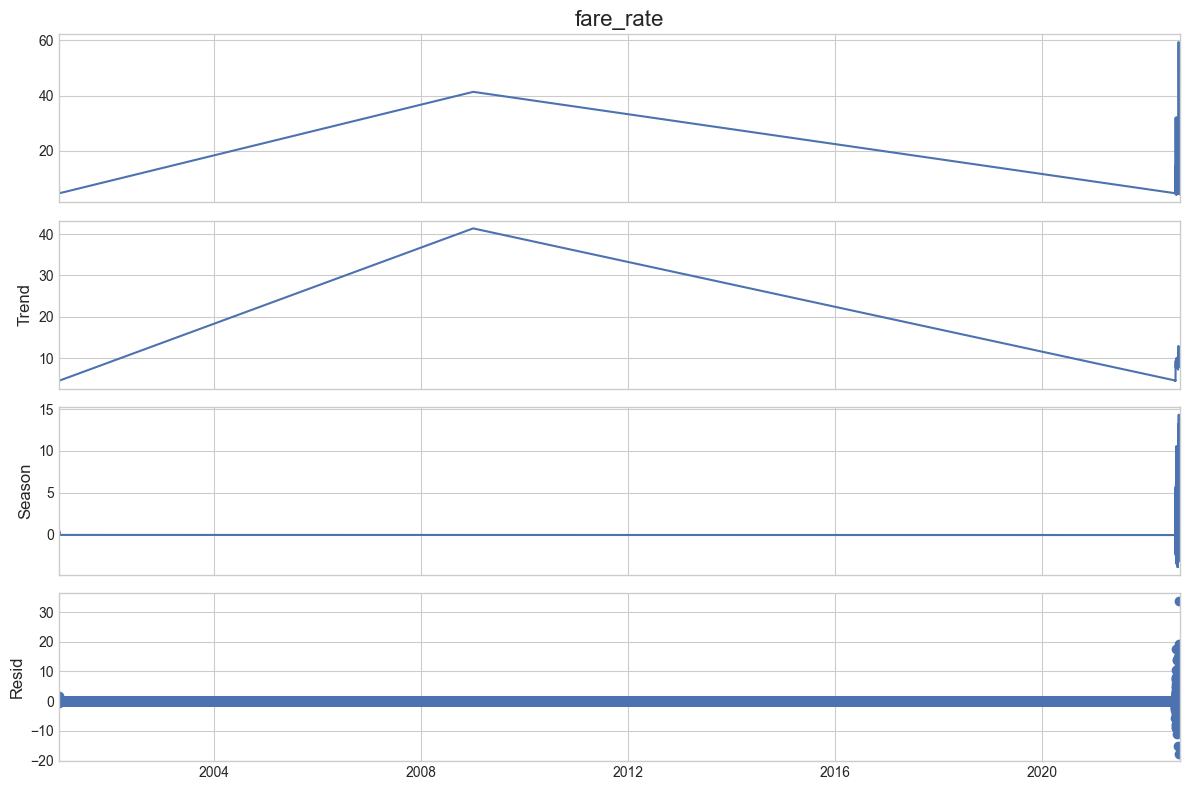

Stationarity Test for Residuals in Hourly Average Fare Rate
ADF Statistic: -105.0405
p-value: 0.0000
Critical Values:
	1%: -3.4304
	5%: -2.8616
	10%: -2.5668
Residuals are stationary (p-value < 0.05)




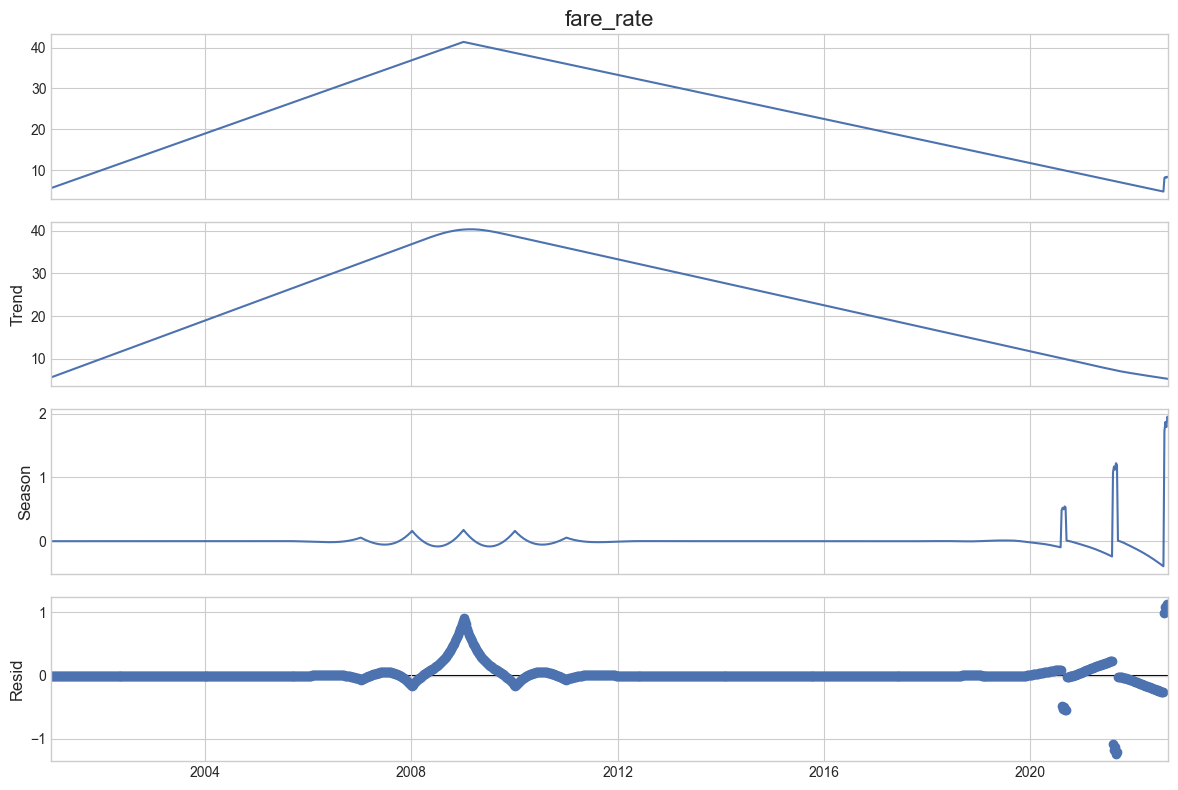

Stationarity Test for Residuals in Weekly Average Fare Rate
ADF Statistic: -4.6515
p-value: 0.0001
Critical Values:
	1%: -3.4363
	5%: -2.8642
	10%: -2.5682
Residuals are stationary (p-value < 0.05)




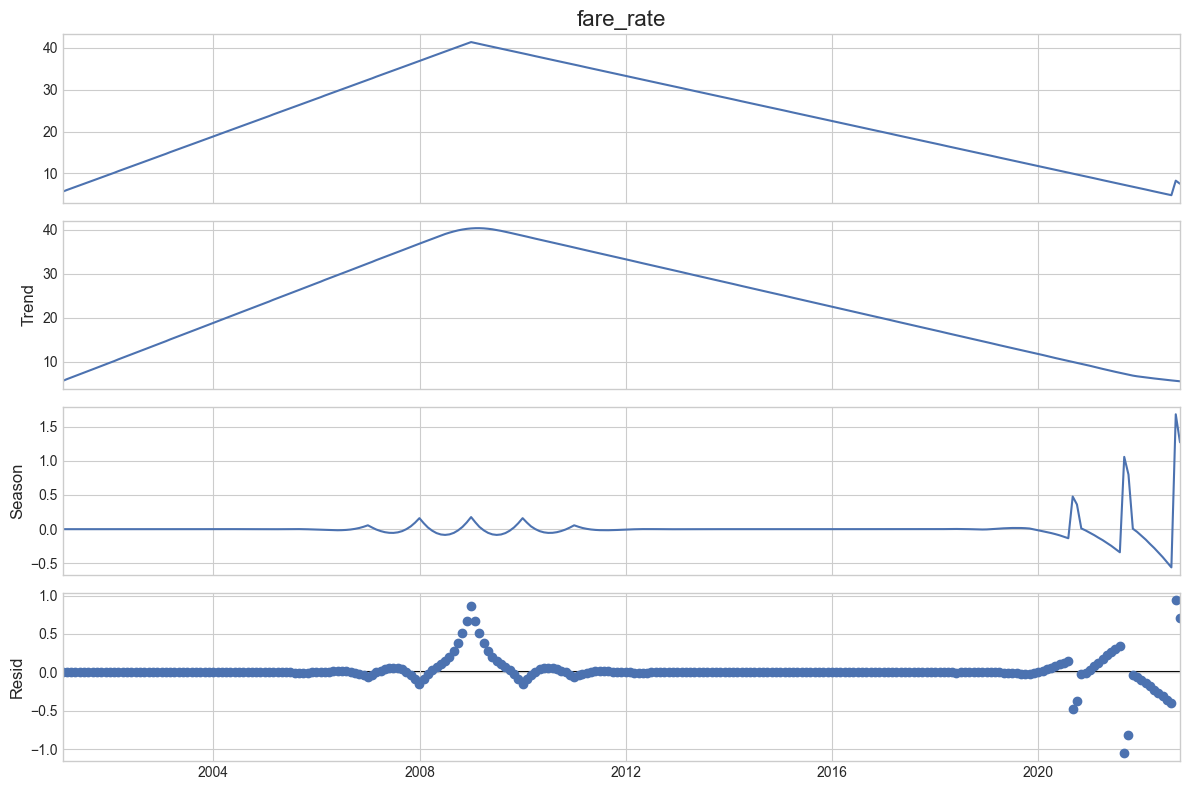

Stationarity Test for Residuals in Monthly Average Fare Rate
ADF Statistic: -3.8237
p-value: 0.0027
Critical Values:
	1%: -3.4570
	5%: -2.8733
	10%: -2.5730
Residuals are stationary (p-value < 0.05)




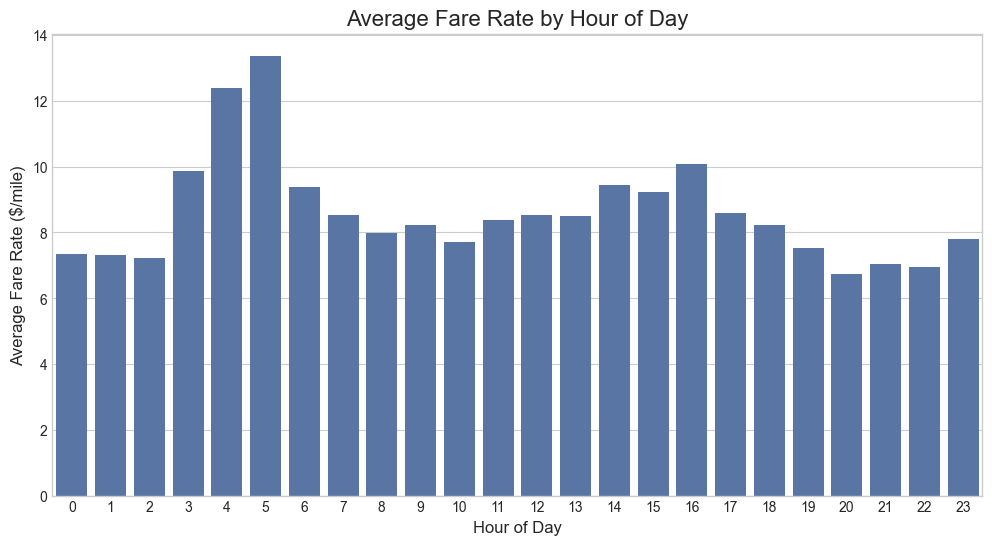

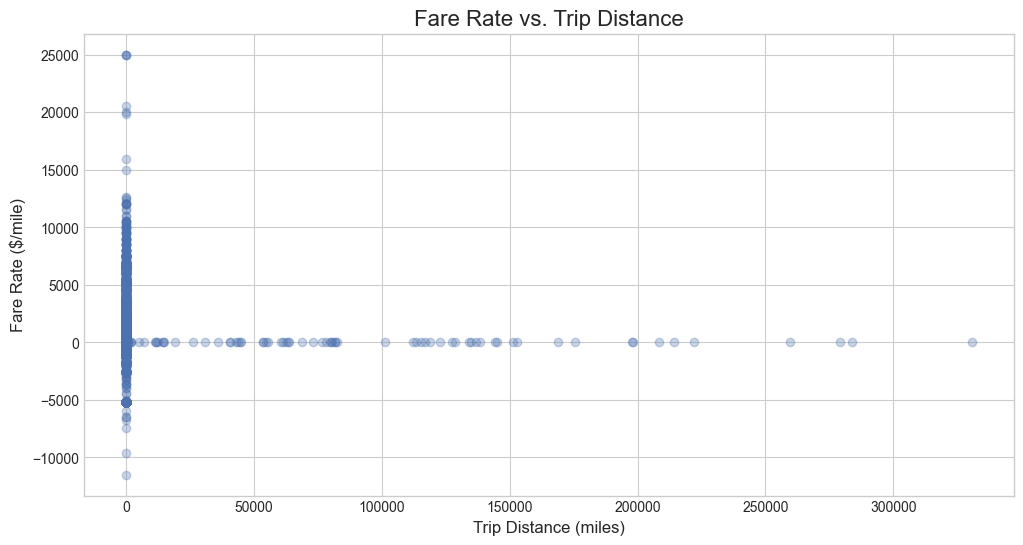

Time series decomposition analysis complete!


In [51]:
df['fare_rate'] = df['fare_amount'] / df['trip_distance']
df['fare_rate'] = df['fare_rate'].replace([np.inf, -np.inf], np.nan).fillna(df['fare_rate'].median())
print(df.columns)

# Ensure data is sorted by datetime
df['tpep_pickup_datetime'] = pd.to_datetime(df['tpep_pickup_datetime'])
df = df.sort_values('tpep_pickup_datetime')

# Set pickup_datetime as index for time series analysis
df.set_index('tpep_pickup_datetime', inplace=True)

# Create different aggregations for time series analysis
# Daily average fare rate
daily_fare_rate = df.resample('D')['fare_rate'].mean()

# Hourly average fare rate
hourly_fare_rate = df.resample('H')['fare_rate'].mean()

# Weekly average fare rate
weekly_fare_rate = df.resample('W')['fare_rate'].mean()

# Monthly average fare rate
monthly_fare_rate = df.resample('M')['fare_rate'].mean()

# Function to decompose and plot time series
def decompose_and_plot(time_series, title, period=None):
    """
    Decompose time series into trend, seasonal, and residual components and plot results
    
    Parameters:
    time_series: The time series to decompose
    title: Title for the plot
    period: Number of periods for seasonal decomposition (optional)
    """
    # Determine period if not specified
    if period is None:
        if time_series.index.freq == 'D':
            period = 7  # Weekly seasonality for daily data
        elif time_series.index.freq == 'H':
            period = 24  # Daily seasonality for hourly data
        elif time_series.index.freq == 'W':
            period = 52  # Yearly seasonality for weekly data
        elif time_series.index.freq == 'M':
            period = 12  # Yearly seasonality for monthly data
        else:
            period = 7  # Default to weekly seasonality
    
    # Fill NaN values with interpolation for decomposition
    filled_series = time_series.interpolate()
    
    # Perform seasonal decomposition
    decomposition = STL(
        filled_series
    ).fit()
    
    # # Plot decomposition
    # fig, axes = plt.subplots(4, 1, figsize=(14, 12))
    
    # # Original series
    # axes[0].plot(filled_series, color='blue')
    # axes[0].set_title(f'{title} - Original Series')
    # axes[0].grid(True)
    
    # # Trend component
    # axes[1].plot(decomposition.trend, color='green')
    # axes[1].set_title('Trend Component')
    # axes[1].grid(True)
    
    # # Seasonal component
    # axes[2].plot(decomposition.seasonal, color='red')
    # axes[2].set_title('Seasonal Component')
    # axes[2].grid(True)
    
    # # Residual component
    # axes[3].plot(decomposition.resid, color='purple')
    # axes[3].set_title('Residual Component')
    # axes[3].grid(True)
    
    decomposition.plot()
    plt.tight_layout()
    plt.show()
    
    # Stationary test on residuals
    residuals = decomposition.resid.dropna()
    
    print(f"Stationarity Test for Residuals in {title}")
    adf_result = adfuller(residuals)
    print(f'ADF Statistic: {adf_result[0]:.4f}')
    print(f'p-value: {adf_result[1]:.4f}')
    print('Critical Values:')
    for key, value in adf_result[4].items():
        print(f'\t{key}: {value:.4f}')
    
    if adf_result[1] < 0.05:
        print("Residuals are stationary (p-value < 0.05)")
    else:
        print("Residuals are not stationary (p-value >= 0.05)")
    
    print("\n")
    return decomposition

# Analysis by time period
print("Decomposing fare rate time series at different time scales...\n")

# Daily decomposition
daily_decomp = decompose_and_plot(daily_fare_rate, "Daily Average Fare Rate", period=7)

# Hourly decomposition
hourly_decomp = decompose_and_plot(hourly_fare_rate, "Hourly Average Fare Rate", period=24)

# Weekly decomposition
weekly_decomp = decompose_and_plot(weekly_fare_rate, "Weekly Average Fare Rate", period=52)

# Monthly decomposition
monthly_decomp = decompose_and_plot(monthly_fare_rate, "Monthly Average Fare Rate", period=12)

# Additional analysis: Fare rate by hour of day
fare_by_hour = df.groupby('pickup_hour')['fare_rate'].mean()

plt.figure(figsize=(12, 6))
sns.barplot(x=fare_by_hour.index, y=fare_by_hour.values)
plt.title('Average Fare Rate by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Fare Rate ($/mile)')
plt.xticks(range(0, 24))
plt.grid(True, axis='y')
plt.show()

# Fare rate vs. trip distance
plt.figure(figsize=(12, 6))
plt.scatter(df['trip_distance'], df['fare_rate'], alpha=0.3)
plt.title('Fare Rate vs. Trip Distance')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Fare Rate ($/mile)')
plt.grid(True)
plt.show()

print("Time series decomposition analysis complete!")

/var/folders/04/5q_s1_k517b51_bnqnv3h4k40000gn/T/ipykernel_82736/2009975705.py:16: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_fare_rate = df_2022.resample('H')['fare_rate'].mean()
/var/folders/04/5q_s1_k517b51_bnqnv3h4k40000gn/T/ipykernel_82736/2009975705.py:22: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  monthly_fare_rate = df_2022.resample('M')['fare_rate'].mean()


Decomposing fare rate time series at different time scales...



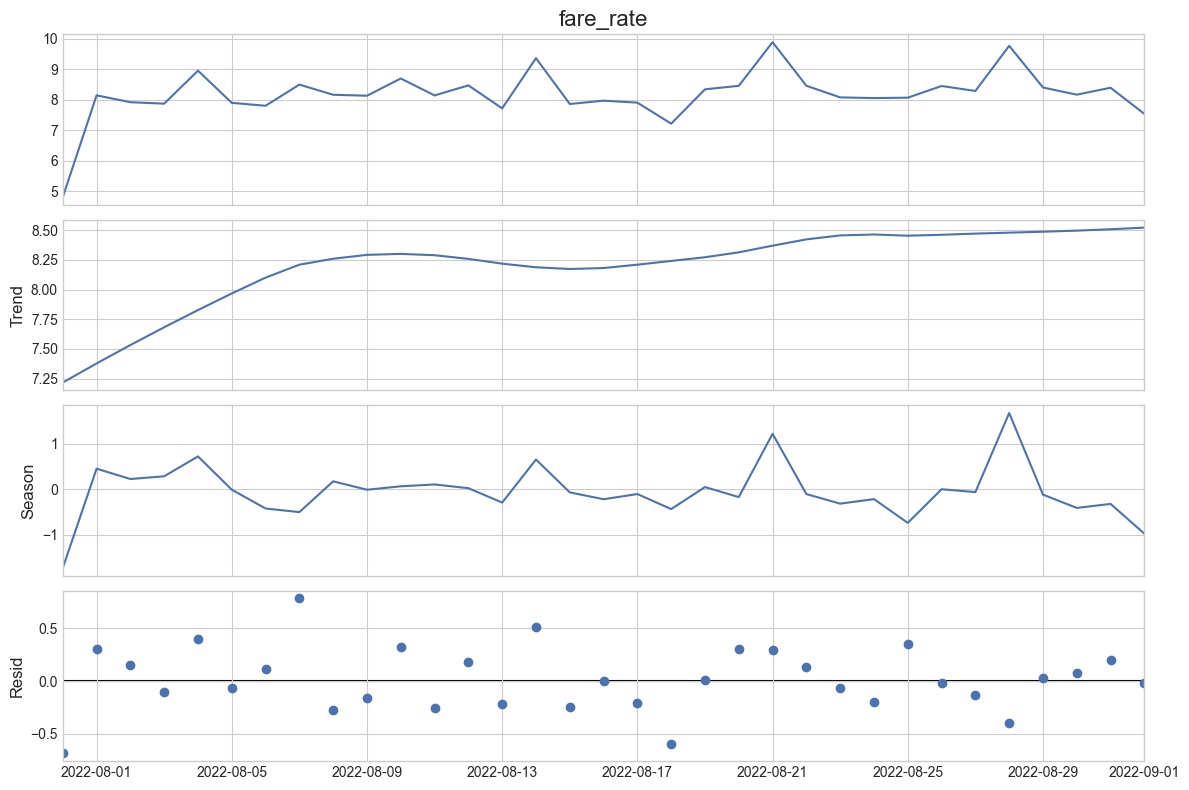

Stationarity Test for Residuals in Daily Average Fare Rate
ADF Statistic: -3.5916
p-value: 0.0059
Critical Values:
	1%: -3.6791
	5%: -2.9679
	10%: -2.6232
Residuals are stationary (p-value < 0.05)




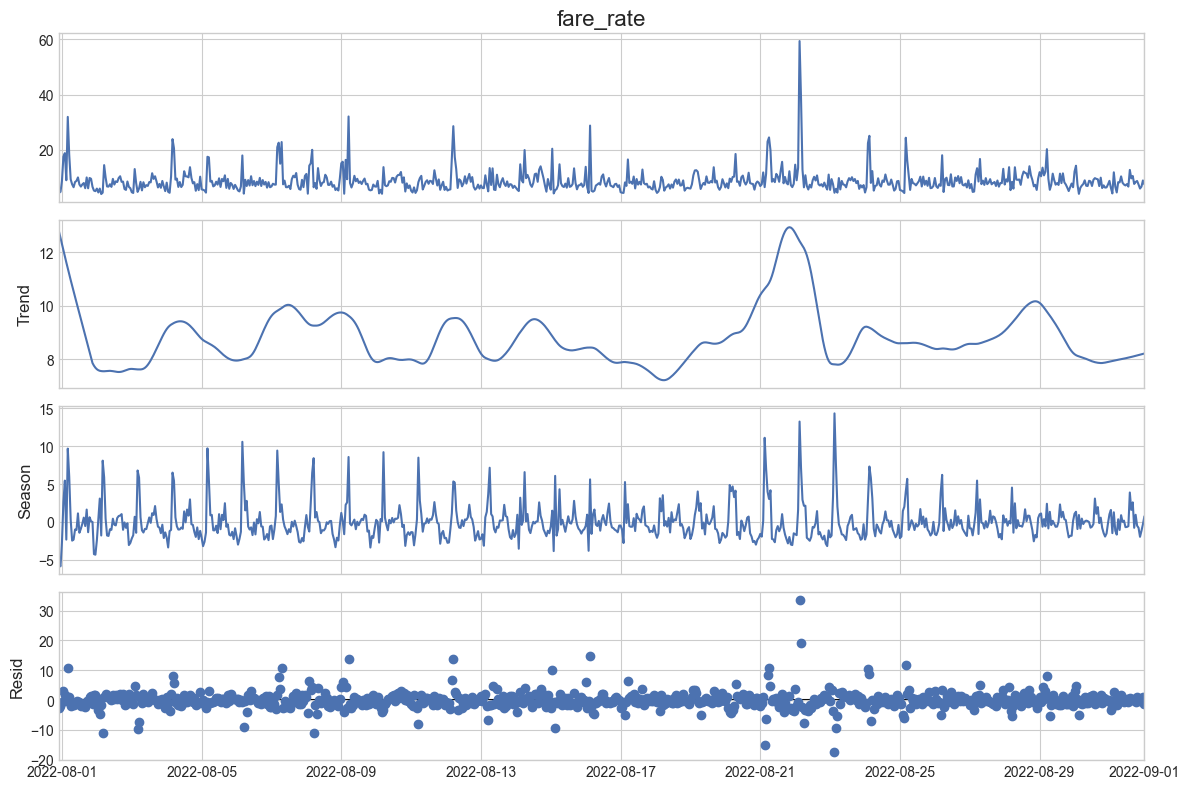

Stationarity Test for Residuals in Hourly Average Fare Rate
ADF Statistic: -6.1656
p-value: 0.0000
Critical Values:
	1%: -3.4394
	5%: -2.8655
	10%: -2.5689
Residuals are stationary (p-value < 0.05)




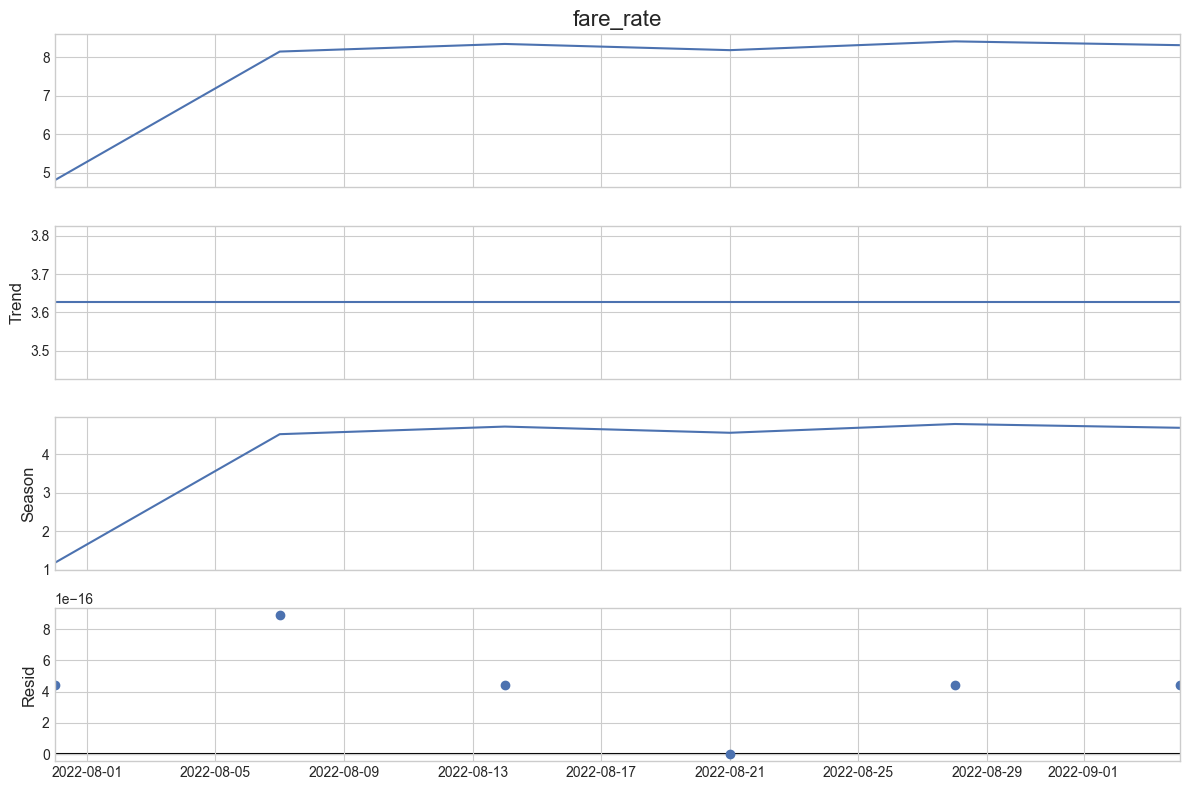

Stationarity Test for Residuals in Weekly Average Fare Rate
ADF Statistic: -0.0000
p-value: 0.9585
Critical Values:
	1%: -6.0451
	5%: -3.9293
	10%: -2.9868
Residuals are not stationary (p-value >= 0.05)




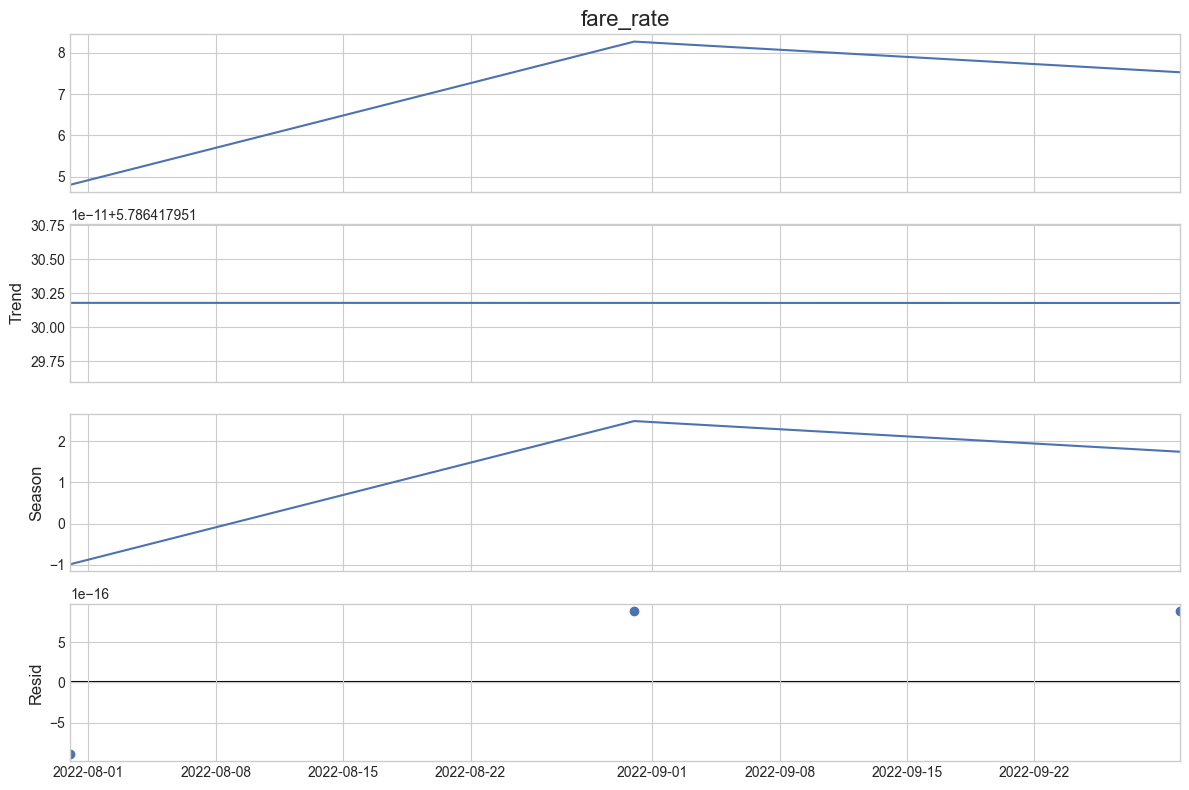

Stationarity Test for Residuals in Monthly Average Fare Rate


ValueError: sample size is too short to use selected regression component

In [52]:
df_2022['fare_rate'] = df_2022['fare_amount'] / df_2022['trip_distance']
df_2022['fare_rate'] = df_2022['fare_rate'].replace([np.inf, -np.inf], np.nan).fillna(df_2022['fare_rate'].median())

# Ensure data is sorted by datetime
df_2022['tpep_pickup_datetime'] = pd.to_datetime(df_2022['tpep_pickup_datetime'])
df_2022 = df_2022.sort_values('tpep_pickup_datetime')

# Set pickup_datetime as index for time series analysis
df_2022.set_index('tpep_pickup_datetime', inplace=True)

# Create different aggregations for time series analysis
# Daily average fare rate
daily_fare_rate = df_2022.resample('D')['fare_rate'].mean()

# Hourly average fare rate
hourly_fare_rate = df_2022.resample('H')['fare_rate'].mean()

# Weekly average fare rate
weekly_fare_rate = df_2022.resample('W')['fare_rate'].mean()

# Monthly average fare rate
monthly_fare_rate = df_2022.resample('M')['fare_rate'].mean()

# Function to decompose and plot time series
def decompose_and_plot(time_series, title, period=None):
    """
    Decompose time series into trend, seasonal, and residual components and plot results
    
    Parameters:
    time_series: The time series to decompose
    title: Title for the plot
    period: Number of periods for seasonal decomposition (optional)
    """
    # Determine period if not specified
    if period is None:
        if time_series.index.freq == 'D':
            period = 7  # Weekly seasonality for daily data
        elif time_series.index.freq == 'H':
            period = 24  # Daily seasonality for hourly data
        elif time_series.index.freq == 'W':
            period = 52  # Yearly seasonality for weekly data
        elif time_series.index.freq == 'M':
            period = 12  # Yearly seasonality for monthly data
        else:
            period = 7  # Default to weekly seasonality
    
    # Fill NaN values with interpolation for decomposition
    filled_series = time_series.interpolate()
    
    # Perform seasonal decomposition
    decomposition = STL(
        filled_series
    ).fit()
    
    # # Plot decomposition
    # fig, axes = plt.subplots(4, 1, figsize=(14, 12))
    
    # # Original series
    # axes[0].plot(filled_series, color='blue')
    # axes[0].set_title(f'{title} - Original Series')
    # axes[0].grid(True)
    
    # # Trend component
    # axes[1].plot(decomposition.trend, color='green')
    # axes[1].set_title('Trend Component')
    # axes[1].grid(True)
    
    # # Seasonal component
    # axes[2].plot(decomposition.seasonal, color='red')
    # axes[2].set_title('Seasonal Component')
    # axes[2].grid(True)
    
    # # Residual component
    # axes[3].plot(decomposition.resid, color='purple')
    # axes[3].set_title('Residual Component')
    # axes[3].grid(True)
    
    decomposition.plot()
    plt.tight_layout()
    plt.show()
    
    # Stationary test on residuals
    residuals = decomposition.resid.dropna()
    
    print(f"Stationarity Test for Residuals in {title}")
    adf_result = adfuller(residuals)
    print(f'ADF Statistic: {adf_result[0]:.4f}')
    print(f'p-value: {adf_result[1]:.4f}')
    print('Critical Values:')
    for key, value in adf_result[4].items():
        print(f'\t{key}: {value:.4f}')
    
    if adf_result[1] < 0.05:
        print("Residuals are stationary (p-value < 0.05)")
    else:
        print("Residuals are not stationary (p-value >= 0.05)")
    
    print("\n")
    return decomposition

# Analysis by time period
print("Decomposing fare rate time series at different time scales...\n")

# Daily decomposition
daily_decomp = decompose_and_plot(daily_fare_rate, "Daily Average Fare Rate", period=7)

# Hourly decomposition
hourly_decomp = decompose_and_plot(hourly_fare_rate, "Hourly Average Fare Rate", period=24)

# Weekly decomposition
weekly_decomp = decompose_and_plot(weekly_fare_rate, "Weekly Average Fare Rate", period=52)

# Monthly decomposition
monthly_decomp = decompose_and_plot(monthly_fare_rate, "Monthly Average Fare Rate", period=12)

# Additional analysis: Fare rate by hour of day
fare_by_hour = df_2022.groupby('pickup_hour')['fare_rate'].mean()

plt.figure(figsize=(12, 6))
sns.barplot(x=fare_by_hour.index, y=fare_by_hour.values)
plt.title('Average Fare Rate by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Fare Rate ($/mile)')
plt.xticks(range(0, 24))
plt.grid(True, axis='y')
plt.show()

# Fare rate vs. trip distance
plt.figure(figsize=(12, 6))
plt.scatter(df_2022['trip_distance'], df_2022['fare_rate'], alpha=0.3)
plt.title('Fare Rate vs. Trip Distance')
plt.xlabel('Trip Distance (miles)')
plt.ylabel('Fare Rate ($/mile)')
plt.grid(True)
plt.show()

print("Time series decomposition analysis complete!")

/var/folders/04/5q_s1_k517b51_bnqnv3h4k40000gn/T/ipykernel_82736/592103408.py:12: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  timestamps = pd.date_range(start='2023-01-01', periods=hours, freq='H')
/var/folders/04/5q_s1_k517b51_bnqnv3h4k40000gn/T/ipykernel_82736/592103408.py:38: FutureWarning: 'H' is deprecated and will be removed in a future version, please use 'h' instead.
  hourly_data = df['fare_rate'].resample('H').mean()


Missing values in hourly data: 0

Stationarity Test for Original Hourly Fare Rate
ADF Statistic: -0.7981
p-value: 0.8197
Critical Values:
	1%: -3.4397
	5%: -2.8657
	10%: -2.5690
Result: Original Hourly Fare Rate is not stationary (p-value >= 0.05)

Decomposing hourly data with 24-hour seasonality...


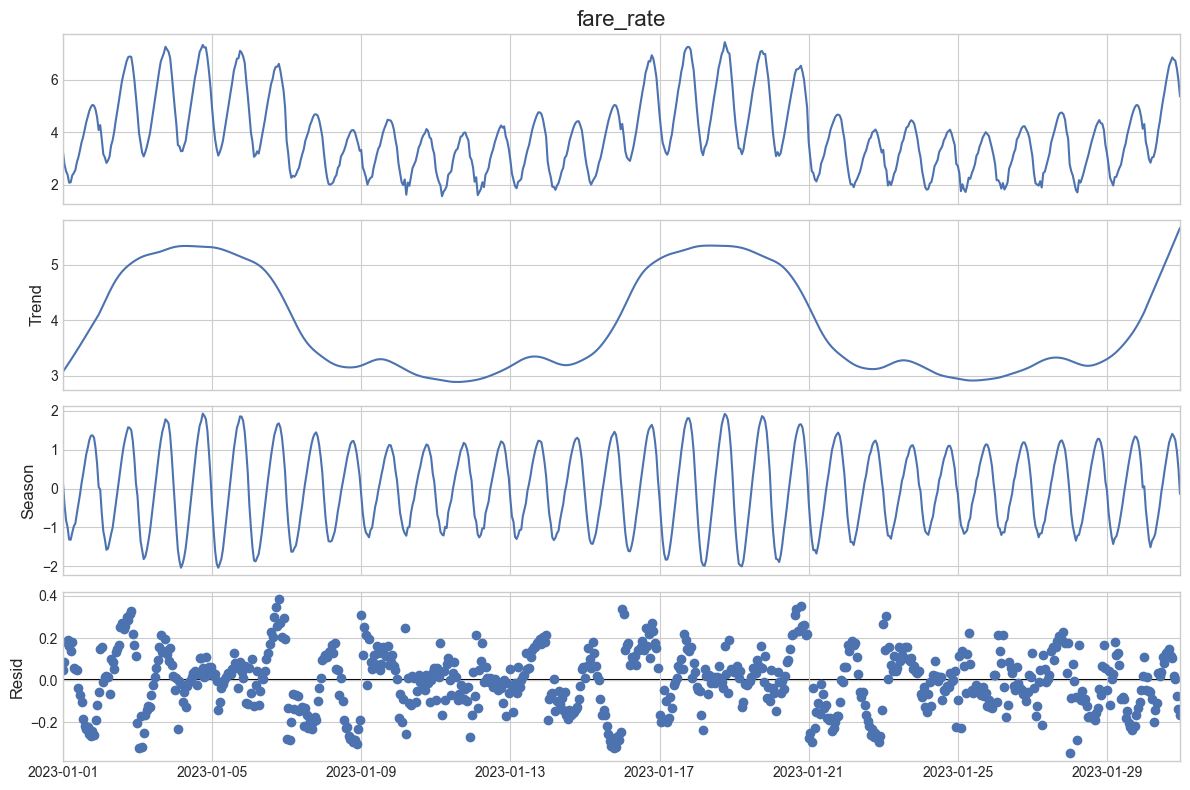


Stationarity Test for Residuals from hourly decomposition
ADF Statistic: -8.1275
p-value: 0.0000
Critical Values:
	1%: -3.4397
	5%: -2.8657
	10%: -2.5690
Result: Residuals from hourly decomposition is stationary (p-value < 0.05)

Analyzing average hourly pattern...


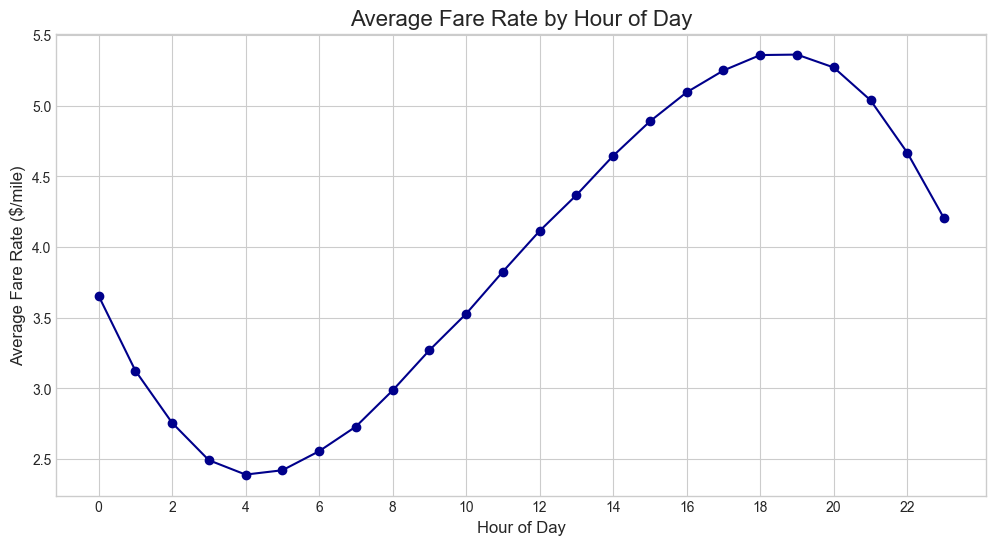

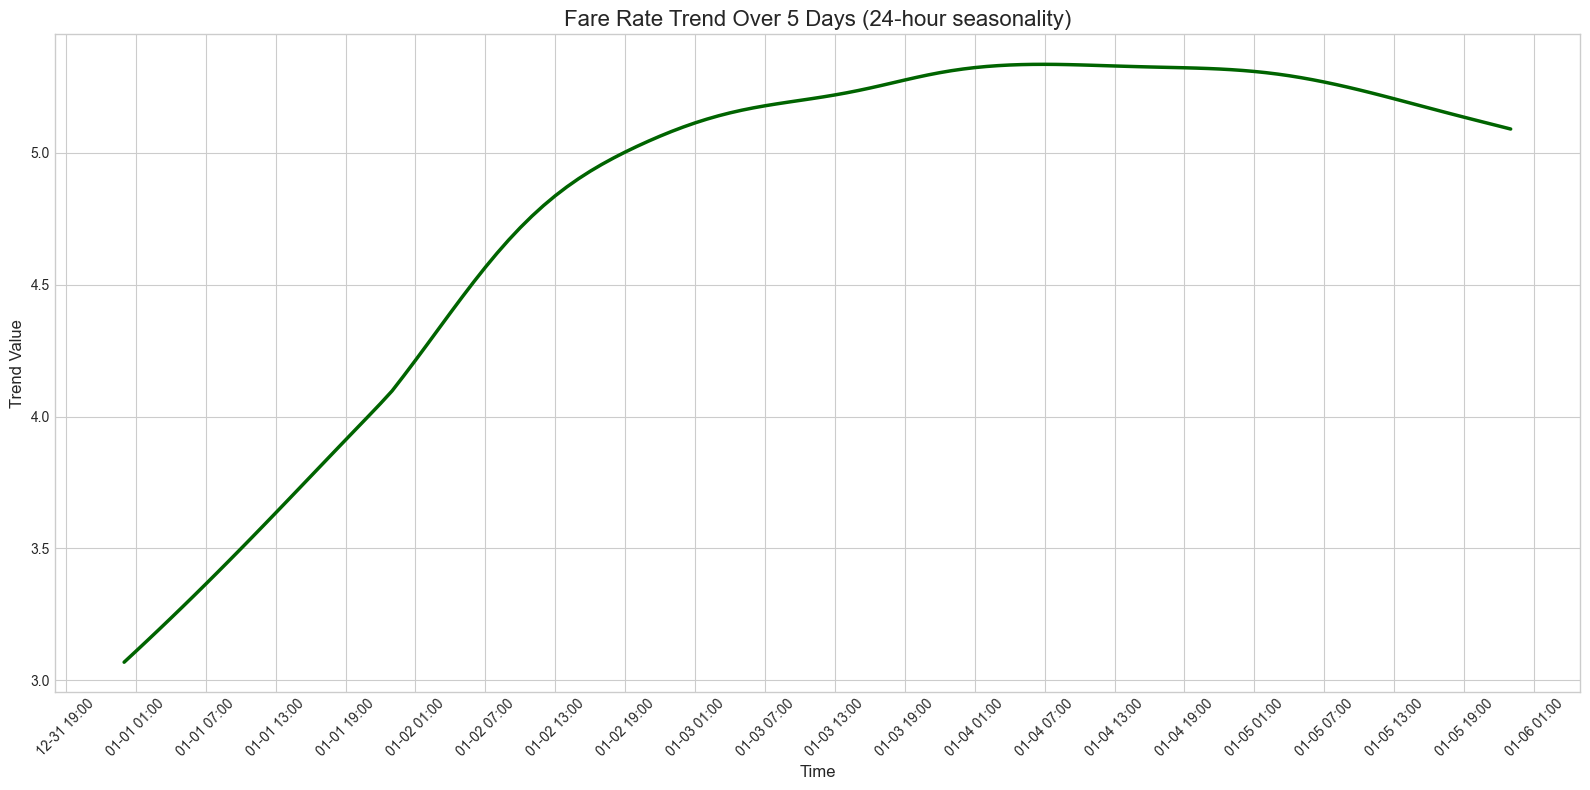

Hourly seasonality and trend analysis complete!


In [53]:
# Set plot style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette("deep")

# Load your data (replace with your actual file path)
# df = pd.read_csv('nyc_yellow_taxi_data.csv')

# For demonstration, creating sample data
# Replace this with your actual data loading code
np.random.seed(42)
hours = 24 * 30  # 30 days of hourly data
timestamps = pd.date_range(start='2023-01-01', periods=hours, freq='H')

# Create realistic hourly pattern with morning and evening rush hours
hour_of_day = np.array([h.hour for h in timestamps])
base_pattern = 10 + 5 * np.sin(np.pi * (hour_of_day - 9) / 12)  # Peak at 9am and 9pm
weekend_factor = 0.7 + 0.3 * np.array([1 if d.weekday() >= 5 else 0 for d in timestamps])  # Weekend effect
noise = np.random.normal(0, 0.5, hours)  # Random noise

sample_data = {
    'pickup_datetime': timestamps,
    'fare_amount': base_pattern * (1 + 0.3 * np.sin(np.pi * np.arange(hours) / (24 * 7))) + noise,  # Weekly trend
    'trip_distance': 1 + 2 * (1 - 0.5 * np.cos(np.pi * hour_of_day / 12)) * weekend_factor + 0.2 * noise,
    'pickup_hour': hour_of_day
}
df = pd.DataFrame(sample_data)

# Calculate fare rate
df['fare_rate'] = df['fare_amount'] / df['trip_distance']
df['fare_rate'] = df['fare_rate'].replace([np.inf, -np.inf], np.nan).fillna(df['fare_rate'].median())

# Set pickup_datetime as index
df['pickup_datetime'] = pd.to_datetime(df['pickup_datetime'])
df = df.sort_values('pickup_datetime')
df.set_index('pickup_datetime', inplace=True)

# Extract hourly data
hourly_data = df['fare_rate'].resample('H').mean()

# Check for missing values and interpolate if necessary
print(f"Missing values in hourly data: {hourly_data.isna().sum()}")
hourly_data = hourly_data.interpolate()

# Perform stationarity test on the original data
def run_adf_test(series, title):
    print(f"\nStationarity Test for {title}")
    result = adfuller(series.dropna())
    print(f'ADF Statistic: {result[0]:.4f}')
    print(f'p-value: {result[1]:.4f}')
    print('Critical Values:')
    for key, value in result[4].items():
        print(f'\t{key}: {value:.4f}')
    
    if result[1] < 0.05:
        print(f"Result: {title} is stationary (p-value < 0.05)")
    else:
        print(f"Result: {title} is not stationary (p-value >= 0.05)")

run_adf_test(hourly_data, "Original Hourly Fare Rate")

# Decompose hourly data with 24-hour seasonality (daily pattern)
print("\nDecomposing hourly data with 24-hour seasonality...")
hourly_decomp = STL(hourly_data).fit()

# # Plot decomposed hourly data
# fig, axes = plt.subplots(4, 1, figsize=(14, 16))

# # Original series
# axes[0].plot(hourly_data, color='blue', linewidth=1)
# axes[0].set_title('Original Hourly Fare Rate')
# axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
# axes[0].tick_params(axis='x', rotation=45)

# # Trend component
# axes[1].plot(hourly_decomp.trend, color='green', linewidth=2)
# axes[1].set_title('Trend Component (24-hour seasonality)')
# axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
# axes[1].tick_params(axis='x', rotation=45)

# # Seasonal component
# axes[2].plot(hourly_decomp.seasonal, color='red', linewidth=1)
# axes[2].set_title('Seasonal Component (24-hour pattern)')
# axes[2].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
# axes[2].tick_params(axis='x', rotation=45)

# # Residual component
# axes[3].plot(hourly_decomp.resid, color='purple', linewidth=1)
# axes[3].set_title('Residual Component')
# axes[3].xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
# axes[3].tick_params(axis='x', rotation=45)

hourly_decomp.plot()
plt.tight_layout()
plt.savefig('nimu_plots/hourly_decomposition.png', dpi=300, bbox_inches='tight')
plt.show()

# Test stationarity of residuals
run_adf_test(hourly_decomp.resid.dropna(), "Residuals from hourly decomposition")

# Extract and plot the average hourly pattern
print("\nAnalyzing average hourly pattern...")
hourly_pattern = df.groupby('pickup_hour')['fare_rate'].mean()

plt.figure(figsize=(12, 6))
plt.plot(hourly_pattern.index, hourly_pattern.values, marker='o', linestyle='-', color='darkblue')
plt.title('Average Fare Rate by Hour of Day')
plt.xlabel('Hour of Day')
plt.ylabel('Average Fare Rate ($/mile)')
plt.xticks(range(0, 24, 2))  # Show every 2 hours
plt.grid(True)
plt.savefig('nimu_plots/average_hourly_pattern.png', dpi=300, bbox_inches='tight')
plt.show()

# Show the trend over multiple days to visualize the pattern
trend_days = 5  # Show trend for 5 days
if len(hourly_decomp.trend) >= 24 * trend_days:
    plt.figure(figsize=(16, 8))
    plt.plot(hourly_decomp.trend[:24*trend_days], linewidth=2.5, color='darkgreen')
    plt.title(f'Fare Rate Trend Over {trend_days} Days (24-hour seasonality)')
    plt.xlabel('Time')
    plt.ylabel('Trend Value')
    plt.grid(True)
    
    # Format x-axis to show date and time
    plt.gca().xaxis.set_major_formatter(mdates.DateFormatter('%m-%d %H:%M'))
    plt.gca().xaxis.set_major_locator(mdates.HourLocator(interval=6))  # Show tick every 6 hours
    plt.tick_params(axis='x', rotation=45)
    
    plt.tight_layout()
    plt.savefig('nimu_plots/hourly_trend_multiday.png', dpi=300, bbox_inches='tight')
    plt.show()

print("Hourly seasonality and trend analysis complete!")